# Week4

### info
```
Shreyas Nayak
240911006
Week4 
dataset : Standup_comic_dataset.csv
```

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [50]:
df = pd.read_excel('Standup_comic_dataset.csv.xlsx')
test_df = pd.read_excel('test_standup.xlsx')
df.dropna(inplace=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5868 entries, 0 to 5928
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   channel_name   5868 non-null   object
 1   video_id       5868 non-null   object
 2   type           5868 non-null   object
 3   video_title    5868 non-null   object
 4   view_count     5868 non-null   int64 
 5   like_count     5868 non-null   int64 
 6   dislike_count  5868 non-null   int64 
 7   favoriteCount  5868 non-null   int64 
 8   commentCount   5868 non-null   int64 
 9   publishedAt    5868 non-null   object
dtypes: int64(5), object(5)
memory usage: 504.3+ KB


In [52]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   channel_name  50 non-null     object
 1   video_title   50 non-null     object
 2   publishedAt   50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


## Question 1
### Train a Multiple Linear Regression model to predict like_count using view_count,commentCount, and dislike_count. Report R² and Adjusted R².

In [53]:
X = df[['view_count', 'commentCount', 'dislike_count']]
y = df['like_count']
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [54]:
print("R²:", model.score(X, y))

R²: 0.812639170585404


In [55]:
n, p = len(y), X.shape[1]
r2_new = 1 - (1 - model.score(X, y)) * (n - 1) / (n - p - 1)
print("Adjusted R²:", r2_new)

Adjusted R²: 0.8125433175007786


In [56]:
pre_df = pd.DataFrame({
    'view_count': [392658, 454505, 199512, 9028403],
    'commentCount': [189, 143, 93, 7769],
    'dislike_count': [0, 69, 23, 308]
})

print("Predictions:", model.predict(pre_df))

Predictions: [ 20104.11709278  21953.97484964  13904.26793692 303105.72313476]


## Question 2
### Now for Q1, split the dataset (80/20) and evaluate model performance using R² and MAE.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [58]:
y_pred = model2.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.8685595338958616
MAE: 20058.2178953436


## Question 3
### Train models on different train-test splits (e.g., 60-40, 80-20, 90-10). Plot the training and testing error. Comment which model is underfitting and overfitting.

In [15]:
splits = [0.4, 0.2, 0.1]
train_errors, test_errors = [], []
for s in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=s, random_state=42)
    model.fit(X_train, y_train)
    train_errors.append(mean_absolute_error(y_train, model.predict(X_train)))
    test_errors.append(mean_absolute_error(y_test, model.predict(X_test)))

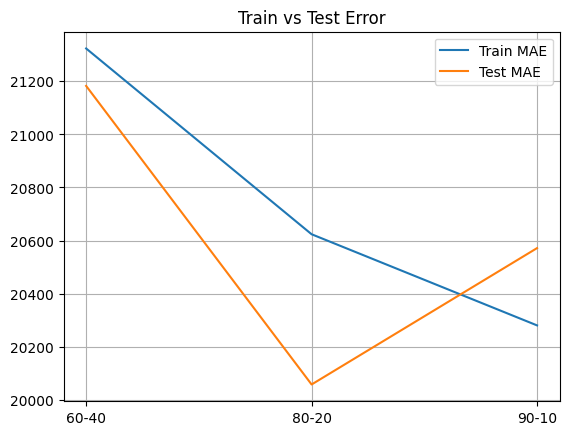

In [16]:
plt.plot(['60-40', '80-20', '90-10'], train_errors, label='Train MAE')
plt.plot(['60-40', '80-20', '90-10'], test_errors, label='Test MAE')
plt.title('Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()

```
From the  above graph we can see that the model at 90-10 is overfitting as train errror is low or accuracy is high but opposite to test case.
in the 60-40 part the model is underfitting as both error and accuracy is bad in test and train
```

## Question 4
### Calculate sentiment scores of video_title. Check correlation with like_count. Vizualise.

In [45]:
sia = SentimentIntensityAnalyzer()

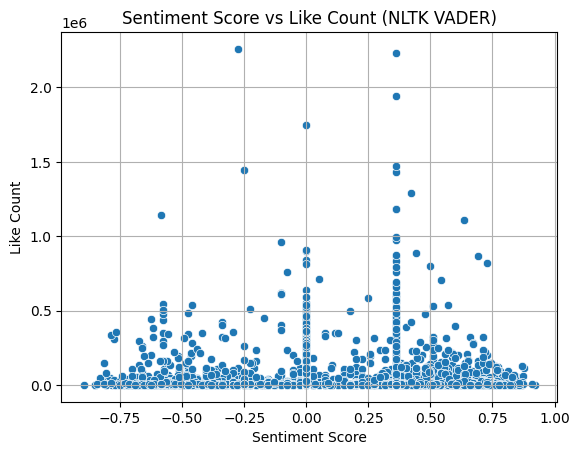

In [17]:
df['sentiment_score'] = df['video_title'].apply(lambda title: sia.polarity_scores(str(title))['compound'])
corr = df['sentiment_score'].corr(df['like_count'])
#print("Q4 Correlation:", corr)
sns.scatterplot(x='sentiment_score', y='like_count', data=df)
plt.title('Sentiment Score vs Like Count (NLTK VADER)')
plt.xlabel('Sentiment Score')
plt.ylabel('Like Count')
plt.grid(True)
plt.show()

## Question 5
### Manually implement Gradient Descent to minimize cost for a simple regression problem:predicting like_count from view_count. Plot the cost function’s convergence.

In [18]:
X_simple = df[['view_count']]
y_simple = df['like_count']
X_norm = (X_simple - X_simple.mean()) / X_simple.std()
y_norm = (y_simple - y_simple.mean()) / y_simple.std()

X_norm.head()

,view_count
0,-0.198077
1,-0.178495
2,-0.259228
3,2.536044
4,-0.151004


In [19]:
m, c = 0.0, 0.0
alpha = 0.01
costs = []

In [20]:
for _ in range(1000):
    y_pred = m * X_norm['view_count'] + c
    error = y_pred - y_norm
    cost = (error ** 2).mean()
    costs.append(cost)
    m -= alpha * (2 * (error * X_norm['view_count']).mean())
    c -= alpha * (2 * error.mean())

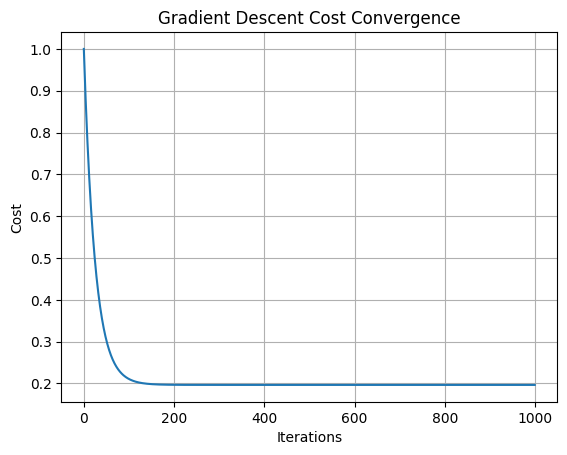

In [21]:
plt.plot(costs)
plt.title('Gradient Descent Cost Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

## Question 6
### Standardize all numerical features before regression. Does it improve model performance in Q1?

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

LinearRegression()

In [24]:
print("R² with Standardization:", model_scaled.score(X_scaled, y))

R² with Standardization: 0.812639170585404


## Question 7
### Make a new feature: title_length. Check correlation between title_length and like_count.

In [32]:
df['title_length'] = df['video_title'].apply(lambda x: len(str(x)))

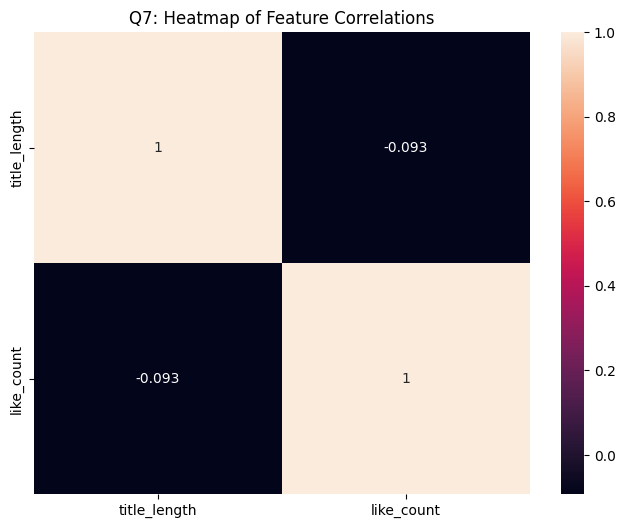

In [33]:
corrr = df[['title_length', 'like_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corrr, annot=True)
plt.title('Q7: Heatmap of Feature Correlations')
plt.show()

In [34]:
corrr

,title_length,like_count
title_length,1.000000,-0.092898
like_count,-0.092898,1.000000


## Question 8
### Create a binary column is_hit:
```
•1 if like_count > median
•0 otherwise
Train a Logistic Regression classifier using view count and comment count to predict is_hit.
Report accuracy, precision, recall, F1.
```

In [35]:
median_like = df['like_count'].median()
df['is_hit'] = (df['like_count'] > median_like).astype(int)
X_cls = df[['view_count', 'commentCount']]
y_cls = df['is_hit']

In [36]:
df['is_hit'].head()

0    1
1    1
2    1
3    1
4    1
Name: is_hit, dtype: int64

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [39]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.919931856899489
Precision: 0.9511343804537522
Recall: 0.8919803600654664
F1 Score: 0.9206081081081081


## Question 9
### Predict view counts based on timestamp for test_standup using original dataset to train the model.

In [40]:
test_df['publishedAt'] = pd.to_datetime(test_df['publishedAt'])
df['publishedAt'] = pd.to_datetime(df['publishedAt'])
df['timestamp'] = df['publishedAt'].astype(np.int64) // 10**9
X_time = df[['timestamp']]
y_time = df['view_count']

In [41]:
model_time = LinearRegression()
model_time.fit(X_time, y_time)

LinearRegression()

In [42]:
test_df['timestamp'] = test_df['publishedAt'].astype(np.int64) // 10**9
print("Predicted view_counts:", model_time.predict(test_df[['timestamp']]))

Predicted view_counts: [ 684138.30142691  710794.1237852  1468583.23559177  834492.34074685
  923866.56193396  663988.68323462 1470725.96479153  901049.41871793
  853792.5707279   693481.76717323 1283756.42660326 1007320.30853937
 1094317.83662187  952227.10919195 2053561.55297397  766375.92762039
  752919.68567128 1222826.5937915  1385026.40111335  763651.51551674
  882901.83012659  795740.67125622 2475933.83637664  729924.16916732
  961333.72259015 1169216.10959028  911040.29613497  695529.1872779
 2503779.21595488  651916.72533937 1450351.21008208  937171.03191838
 1057271.88821022  950050.60045844 1196369.91672736 1793784.47427178
  766006.15921778  906830.75708264 1269669.45541157  650010.52437199
  908127.13427309  932204.22025653  732748.31835913  917662.98178056
  885633.00576325  700446.3186688  1230897.180739    658575.34970155
 1589368.14293289 1528757.80721819]


## Question 10
### Use TF-IDF vectorization on video_title and use it in a linear regression model to predict view_count, for the data in file test_standup.

```
Note : TOOK a lot of help for Gen AI's for this one question sryyy
```

In [43]:
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(df['video_title'].astype(str))
model_tfidf = LinearRegression()
model_tfidf.fit(X_tfidf, df['view_count'])

LinearRegression()

In [44]:
X_test_tfidf = tfidf.transform(test_df['video_title'].astype(str))
print("Q10 TF-IDF Predicted view_counts:", model_tfidf.predict(X_test_tfidf))

Q10 TF-IDF Predicted view_counts: [ 2.33969731e+06  6.41563585e+06 -6.19369867e+06 -2.67340069e+06
  1.62975332e+04  1.73098467e+06  4.91185016e+06  9.11484637e+06
  1.12998651e+06  4.02024983e+06  1.55549103e+06  8.56633078e+05
  6.20990755e+05  3.28644606e+07  2.23171759e+06  2.24240278e+06
 -1.83303585e+05  1.67068466e+07  4.79386203e+06 -1.41453336e+06
 -3.69141244e+05  3.18913163e+03 -7.53995736e+06 -3.27681627e+06
 -5.34464699e+06  2.44580377e+05  8.76458465e+05 -1.25611737e+06
  9.27309180e+05  9.55416450e+06  6.63738011e+06 -8.26912110e+06
  9.27309180e+05  5.17122580e+06  6.84789545e+06  6.60420188e+06
  3.42831703e+05  1.43677507e+06 -3.48394801e+05 -7.37540765e+05
  1.69632391e+06 -1.18054291e+07  1.14788932e+06  3.02307199e+06
 -5.58383904e+06 -2.47189632e+06 -2.33949553e+06  4.50848028e+06
  1.31084087e+06 -2.53405173e+06]


# Thank yOU